## Overview

CNN-GRU Setup for prediction out of 2D timeseries data

finding out of impact of training on "wrong" year of the saison

----
## Data:

-2D Space - Timeseries

-predicting 1 feature out of 7 variables

-Forecasting 1 timestep (not the following)

-------
Peter Resch, 3.6.

next step: get the window method in the dataset class to the agreed format

In [181]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
import os

import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

import xarray as xr

rSeed=42

SavePlots = False

## Loading Data

In [182]:
!cd ../../../datasets/small_grid/ && ls -l

total 186776
drwxrwxr-x 2 peter peter    4096 Jun  4 15:23 dataloaders
-rw-rw-r-- 1 peter peter   11185 Jun  4 10:28 grib_to_pd_dataset.ipynb
-rw-rw-r-- 1 peter peter 9688560 Jun  4 09:03 grid-timeseries_sel_vars_2015.grib
-rw-rw-r-- 1 peter peter 6204500 Jun  4 10:02 grid-timeseries_sel_vars_2015.grib.nc
-rw-rw-r-- 1 peter peter 9715104 Jun  4 09:06 grid-timeseries_sel_vars_2016.grib
-rw-rw-r-- 1 peter peter 6221492 Jun  4 10:05 grid-timeseries_sel_vars_2016.grib.nc
-rw-rw-r-- 1 peter peter 9688560 Jun  4 09:06 grid-timeseries_sel_vars_2017.grib
-rw-rw-r-- 1 peter peter 6204500 Jun  4 10:08 grid-timeseries_sel_vars_2017.grib.nc
-rw-rw-r-- 1 peter peter 9688560 Jun  4 09:06 grid-timeseries_sel_vars_2018.grib
-rw-rw-r-- 1 peter peter 6204500 Jun  4 10:11 grid-timeseries_sel_vars_2018.grib.nc
-rw-rw-r-- 1 peter peter 9688560 Jun  4 09:07 grid-timeseries_sel_vars_2019.grib
-rw-rw-r-- 1 peter peter 6204500 Jun  4 10:14 grid-timeseries_sel_vars_2019.grib.nc
-rw-rw-r-- 1 peter peter 9715104 

In [183]:
year="2020"
ending = ".grib.nc"
filename="../../../datasets/small_grid/grid-timeseries_sel_vars_"+year+ending

# Open the NetCDF files using xarray
ds={}
ds[year]= xr.open_dataset(filename)
ds1=ds[year]
ds["2021"]=ds1
ds.keys()

#combining the dict datasets into one xarray dataset
ds_combined = xr.concat([ds[year] for year in ds.keys()], dim='time')
ds_combined

ds_spring = ds_combined.sel(time=ds_combined['time.season'] == 'MAM')
ds_summer = ds_combined.sel(time=ds_combined['time.season'] == 'JJA')
ds_autumn = ds_combined.sel(time=ds_combined['time.season'] == 'SON')
ds_winter = ds_combined.sel(time=ds_combined['time.season'] == 'DJF')
df=ds1.sel(time=ds1['time.month'] == 3)#march
print(df)



ds=ds1.sel(time=ds1['time.season'] == 'MAM')

ds_test=ds_summer
ds_test

<xarray.Dataset> Size: 527kB
Dimensions:  (time: 744, lat: 5, lon: 5)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-03-01 ... 2020-03-31T23:00:00
  * lat      (lat) float64 40B 56.0 55.75 55.5 55.25 55.0
  * lon      (lon) float64 40B 12.0 12.25 12.5 12.75 13.0
Data variables:
    10u      (time, lat, lon) float32 74kB ...
    10v      (time, lat, lon) float32 74kB ...
    2t       (time, lat, lon) float32 74kB ...
    sp       (time, lat, lon) float32 74kB ...
    tp       (time, lat, lon) float32 74kB ...
    str      (time, lat, lon) float32 74kB ...
    tcc      (time, lat, lon) float32 74kB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Fri May 29 16:53:13 2026: cdo -f nc copy grid-timeseries_se...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...


<xarray.Dataset> Size: 3MB
Dimensions:  (time: 4416, lat: 5, lon: 5)
Coordinates:
  * time     (time) datetime64[ns] 35kB 2020-06-01 ... 2020-08-31T23:00:00
  * lat      (lat) float64 40B 56.0 55.75 55.5 55.25 55.0
  * lon      (lon) float64 40B 12.0 12.25 12.5 12.75 13.0
Data variables:
    10u      (time, lat, lon) float32 442kB -0.8836 -1.666 ... -3.301 -3.232
    10v      (time, lat, lon) float32 442kB 1.578 0.8734 ... -6.126 -5.847
    2t       (time, lat, lon) float32 442kB 286.5 284.2 281.8 ... 289.7 289.9
    sp       (time, lat, lon) float32 442kB 1.028e+05 1.028e+05 ... 1.019e+05
    tp       (time, lat, lon) float32 442kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    str      (time, lat, lon) float32 442kB -3.267e+05 -3.028e+05 ... -3.926e+05
    tcc      (time, lat, lon) float32 442kB 0.0 0.0 0.0 ... 0.02005 0.04669
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Fri May 29 16:53:13 2026: cdo -f nc copy grid-timeseries_se...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [184]:
class TimeseriesDatasetPipeline:
    """Pipeline to convert xarray Dataset to PyTorch Dataset with optional scaling."""
    
    def __init__(self, ds,lag_selection=None, forecast_horizon=24,forecast_hours=1,forecast_var=5):
        """
        Initialize the pipeline.
        
        Args:
            ds: xarray.Dataset with dimensions (time, lat, lon)
            scaler: sklearn scaler object (optional, e.g., StandardScaler)
            forecast_lag: number of past timesteps to use as input
            forecast_horizon: number of future timesteps to predict
        """
        self.ds = ds
        self.lag_selection = lag_selection
        self.forecast_horizon = forecast_horizon
        self.forecast_var = forecast_var
        self.forecast_hours = forecast_hours
        self.data = None
        self._prepare_data()
        if self.forecast_var >= self.data.shape[1]:
            raise ValueError(f"forecast_var index {self.forecast_var} is out of bounds for data with {self.data.shape[1]} variables.")
    

    def get_input_shape(self):
        """Return the shape of the input data (time, variables, space)."""
        return self.ds.to_array().values.shape if self.ds is not None else None

    def _prepare_data(self):
        """Convert xarray to numpy, flatten spatial dimensions and reshape."""
        stacked = self.ds.to_array()
        self.data = stacked.values.transpose(1, 0, 2,3)#(time, variables, lat,lon)
        print("Data prepared with shape:", self.data.shape)


    def scale_X(self,shaped_data,scaler_set=None):
        """Apply each scaler to the corresponding variable."""
        scaled=shaped_data
        if scaler_set is None:  sc_set=np.array([])
        else: sc_set=scaler_set
        for i in range(scaled.shape[-3]):#in vars
            reshaped_var = scaled[:,:, i, :].reshape(-1, 1)
            if scaler_set is None:#scaler set not functional
                sc_set = np.append(sc_set, sklearn.preprocessing.StandardScaler().fit(reshaped_var))
            sh=scaled.shape[0], scaled.shape[1],scaled.shape[3], scaled.shape[4]
            scaled[:,:, i, :] = sc_set[i].transform(reshaped_var).reshape(sh)
        return scaled, sc_set
   
    def scale_y(self,shaped_data,scaler=None):
        """Apply scaler to the corresponding variable."""
        scaled=shaped_data
        reshaped_var = scaled.reshape(-1, 1)
        if scaler is None:
            scaler=sklearn.preprocessing.StandardScaler().fit(reshaped_var)
        sh=scaled.shape[0],1,scaled.shape[2], scaled.shape[3]
        scaled = scaler.transform(reshaped_var).reshape(sh)
        return scaled,scaler
    



    def create_windowed_dataset_from_idxlist(self, idx_list):
        """Create X and y using moving window method."""
        data = self.data
        if self.lag_selection:
            max_lag = max(self.lag_selection)+1
        else:
            raise ValueError("forecast_lag_selection must be provided.")
        
        X, y = [], []
        for i in idx_list:
            #print(f"Processing index {i} with lag selection {self.lag_selection} and forecast horizon {self.forecast_horizon}.")
            #print(f"\nforecast horizon: {self.forecast_horizon}, forecast var: {self.forecast_var}, lag selection: {self.lag_selection}")
            if i+max_lag+self.forecast_horizon >= len(data):
                print(f"Skipping index {i} due to insufficient data for lag selection and forecast horizon.")
                continue
            #testing, if there is enough consecutive data for the selected lags and forecast horizon in the time dimension, if not, skip this index
            last_timespan_idx=i+max_lag+self.forecast_horizon
            if self.ds.time[last_timespan_idx].values - self.ds.time[i].values > np.timedelta64(max_lag+self.forecast_horizon, 'h'):
                print(f"Skipping index {i} due to insufficient consecutive data for forecast horizon.")
                continue
            
            #print("Original data shape:", data.shape)
            data_filtered = []#filtering data based on lag selection
            for t in self.lag_selection:
                data_filtered.append(data[i+t,:,:])
            xd = np.array(data_filtered)  # (lag_selection, variables, space)
            #print("data_filtered:", getattr(xd, "shape", None))
            
            #xd=np.delete(data_filtered, self.forecast_var, axis=1)# Remove target variable from input
            #print("xd:", getattr(xd, "shape", None), type(xd),"\n")
            X.append(xd)
            yd=data[i+self.forecast_horizon,self.forecast_var,:]  # Only target variable
            yd=yd.reshape(1, yd.shape[0], yd.shape[1])
            y.append(yd)
            #print("yd:", getattr(yd, "shape", None), type(yd))

            #return test_end

        X = np.array(X) 
        y = np.array(y)  
        print("X:", X.shape, type(X))   # (samples, lag, variables, space)
        print("y:",y.shape, type(y))    # (samples, horizon, pred variable, space)
        return X,y


    def create_random_train_test_split_idx(self, test_size=0.2, random_state=None):
        """Create random train/test split indices."""
        total_samples = self.data.shape[0] - max(self.lag_selection) - self.forecast_horizon
        indices = np.arange(total_samples)
        train_idx, test_idx = train_test_split(indices, test_size=test_size, random_state=random_state)
        return train_idx, test_idx
    

    def to_scaled_pytorch_train_test_dataloaders(self, batch_size=32, test_size=0.2, random_state=None):
        """Create PyTorch DataLoader with random train/test split."""
        train_idx, test_idx = self.create_random_train_test_split_idx(test_size=test_size, random_state=random_state)
        X_train, y_train = self.create_windowed_dataset_from_idxlist(train_idx)
        X_test, y_test = self.create_windowed_dataset_from_idxlist(test_idx)
        
        #scale
        X_train_sc, scaler_set = self.scale_X(X_train)
        X_test_sc, _ = self.scale_X(X_test, scaler_set=scaler_set)
        y_train_sc, scaler_y = self.scale_y(y_train)
        y_test_sc, _ = self.scale_y(y_test, scaler=scaler_y)

        train_dataset = TimeseriesPyTorchDataset(X_train_sc, y_train_sc)
        test_dataset = TimeseriesPyTorchDataset(X_test_sc, y_test_sc)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size)
        test_loader = DataLoader(test_dataset, batch_size=batch_size)
        
        return train_loader, test_loader
    



    def to_pytorch_dataloader(self, batch_size=32, shuffle=True):
        """Convert to PyTorch DataLoader."""
        X, y = self.create_windowed_dataset_from_idxlist(list(range(self.data.shape[0] - max(self.lag_selection) - self.forecast_horizon)))
        print("dataloader not scaled!")
        dataset = TimeseriesPyTorchDataset(X, y)
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


    def to_scaled_pytorch_dataloader(self, batch_size=32, shuffle=True):
        """Convert to scaled PyTorch DataLoader."""
        X, y = self.create_windowed_dataset_from_idxlist(list(range(self.data.shape[0] - max(self.lag_selection) - self.forecast_horizon)))
        #print("creating scaled dataloader...")
        X_scaled, scaler_set = self.scale_X(X)
        #print("X scaled with scaler set:", scaler_set)
        y_scaled, scaler_y = self.scale_y(y)
        #print("y scaled with scaler y:", scaler_y)
        dataset = TimeseriesPyTorchDataset(X_scaled, y_scaled)
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)#, scaler_set, scaler_y



class TimeseriesPyTorchDataset(Dataset):
    """PyTorch Dataset for timeseries data."""
    
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [185]:
#Testing
lag_selection=[0, 24, 48, 60, 66, 69, 71]
lag_selection=[0, 2,3]
pipeline = TimeseriesDatasetPipeline(ds1, lag_selection=lag_selection, forecast_horizon=1, forecast_var=5)
idxlist=[1, 2, 3, 4]#just a test list of indices
X,y=pipeline.create_windowed_dataset_from_idxlist(idxlist)

#X[0,0,0,:].shape#25
#X[0,0,0]
X.shape#(4, 3, 7, 5, 5)

print()
X_sc=pipeline.scale_X(X,X_sc[1])
y_sc=pipeline.scale_y(y)
X_sc[1]

tr,te=pipeline.create_random_train_test_split_idx(test_size=0.5)
tr



Data prepared with shape: (8784, 7, 5, 5)
X: (4, 3, 7, 5, 5) <class 'numpy.ndarray'>
y: (4, 1, 5, 5) <class 'numpy.ndarray'>



array([6957, 7901, 2198, ...,   81, 8250, 4803], shape=(4390,))

In [189]:
#if dataloaders are not already created, create them and save for later use
folder_path = "../../../datasets/small_grid/dataloaders/"

if not (os.path.exists(folder_path + "dataloader_train.pt") and os.path.exists(folder_path + "dataloader_val.pt") and os.path.exists(folder_path + "dataloader_test.pt")):
    print("Dataloaders not found. Creating and saving dataloaders...")
    batch_size=64
    lag_selection=[0, 24, 48, 60, 66, 69, 71]
    validate_ratio=0.20

    pipeline= TimeseriesDatasetPipeline(ds, lag_selection=lag_selection, forecast_horizon=1, forecast_var=5)
    dataloader_train,dataloader_val=pipeline.to_scaled_pytorch_train_test_dataloaders(batch_size=batch_size, test_size=validate_ratio, random_state=rSeed)

    pipeline_test = TimeseriesDatasetPipeline(ds_test, lag_selection=lag_selection, forecast_horizon=1, forecast_var=5)
    dataloader_test = pipeline_test.to_scaled_pytorch_dataloader(batch_size=batch_size, shuffle=False)

    #saving dataloaders for later use
    torch.save(dataloader_train, folder_path + "dataloader_train.pt")
    torch.save(dataloader_val, folder_path + "dataloader_val.pt")
    torch.save(dataloader_test, folder_path + "dataloader_test.pt")
    print("dataloaders saved successfully.")

else:
    print("Dataloaders already exist. Loading from disk...")
    dataloader_train = torch.load(folder_path + "dataloader_train.pt", weights_only=False)
    dataloader_val = torch.load(folder_path + "dataloader_val.pt", weights_only=False)
    dataloader_test = torch.load(folder_path + "dataloader_test.pt", weights_only=False)
    print("Dataloaders loaded successfully.")

Dataloaders already exist. Loading from disk...
Dataloaders loaded successfully.


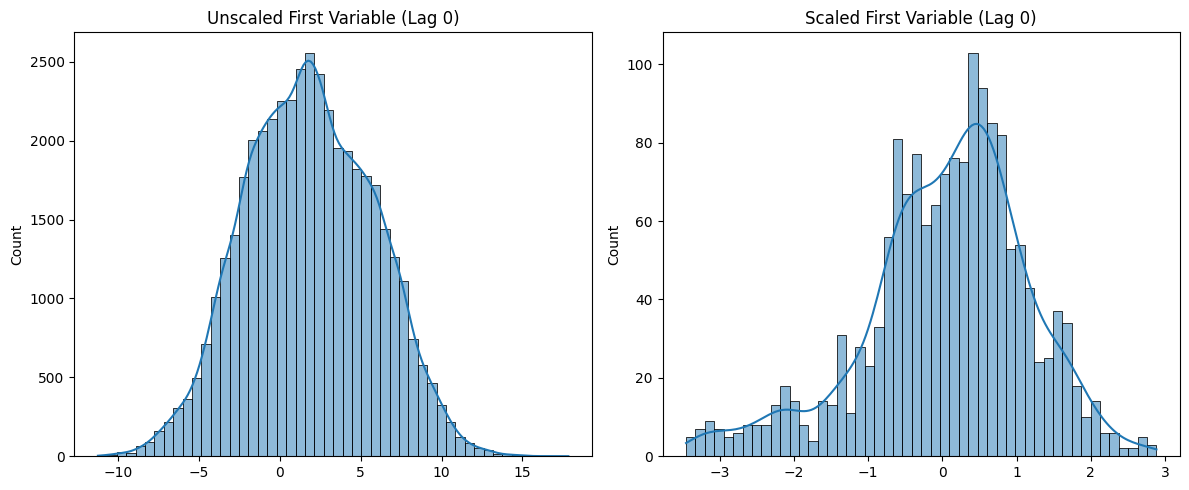

In [190]:
#Histogram of first variable scaled and unscaled for training dataloader
X_train, _ = next(iter(dataloader_train))
X_train_unscaled = pipeline.data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_train_unscaled[:, 0, 0, :].flatten(), bins=50, kde=True)
plt.title("Unscaled First Variable (Lag 0)")
plt.subplot(1, 2, 2)
sns.histplot(X_train[:, 0, 0, :].flatten(), bins=50, kde=True)
plt.title("Scaled First Variable (Lag 0)")
plt.tight_layout()

In [191]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")


hidden_size=16

class CNN_GRU(nn.Module):
    def __init__(self,in_channels=7,hidden_size=16,lat_size=5,lon_size=5):
        super().__init__()

        #compressing space
        def double_conv(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True)
            )
        self.conv1 = double_conv(in_channels, 16)
        self.maxpool = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = double_conv(16, 32)

        #compressing time
        self.gru = nn.GRU(input_size=32,hidden_size=32*25, num_layers=1,dropout=0.2,batch_first=True)
        
        #expanding space
        self.deconv1 = nn.ConvTranspose2d(32, 16, kernel_size=3, padding=1)
        self.deconv2 = nn.ConvTranspose2d(16, 1, kernel_size=3, padding=1)


    def forward(self, x):
        #print("starting forward:",x.shape)
        x_gru=[]
        #recognize patterns of the spatial data with CNN
        for time in range(x.shape[1]):
            #print(time)
            cnn_in=x[:, time, :, :]
            #print("time,cnn_in.shape:",time,cnn_in.shape)
            cnn_in=self.conv1(cnn_in)
            #print("after conv1:",cnn_in.shape)
            cnn_in = self.maxpool(cnn_in)
            #print("after maxpool:",cnn_in.shape)
            cnn_in = self.conv2(cnn_in)
            #print("after conv2:",cnn_in.shape)
            cnn_in = self.maxpool(cnn_in)
            #print("after maxpool:",cnn_in.shape)
            cnn_in = cnn_in.view(cnn_in.size(0), -1)  # Flatten for GRU input
            #print("after flatten:",cnn_in.shape)
            x_gru.append(cnn_in)
        x_gru = torch.stack(x_gru, dim=1)
        #print("shaped for GRU:",x_gru.shape)#(batch, time, convoluted features with space)

        #decoding the temporal patterns with GRU
        x,_ = self.gru(x_gru)#x:(batch, time, hidden_size)
        x = x[:,-1,:].view(x.shape[0],32,5,5)##(batch, last hidden_size,lat_size,lon_size)
        #print("after GRU:",x.shape)
        x=self.deconv1(x)
        #print("after deconv1:",x.shape)
        x=self.deconv2(x)
        #print("after deconv2:",x.shape)
        return x# 


cnn_gru_model=CNN_GRU().to(device)
print(cnn_gru_model)

# Loss function and optimizer
loss_fcn = nn.MSELoss()
optimizer_cnn_gru = AdamW(cnn_gru_model.parameters(), lr=1e-3, weight_decay=1e-4)

Using cpu device
CNN_GRU(
  (conv1): Sequential(
    (0): Conv2d(7, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (maxpool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (gru): GRU(32, 800, batch_first=True, dropout=0.2)
  (deconv1): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


/home/peter/anaconda3/envs/appmlenv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


In [192]:
def train(dataloader, model, loss_fn, optimizer,device):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        #print(X.shape, y.shape)
        X, y = X.to(device), y.to(device)
        #print(X.shape, y.shape)
        pred = model(X)#.squeeze()
        #print(pred)#.shape)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"Train Loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    return loss.item()



def test(dataloader, model, loss_fn,device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            predictions = model(X)
            test_loss += loss_fn(predictions, y).item()

            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    test_loss /= num_batches
    y_pred = np.concatenate(all_predictions)#[:,:,0]
    y_true = np.concatenate(all_targets)#[:,:,0]
    #print(f"y_true shape: {y_true.shape}, y_pred shape: {y_pred.shape}")

    # Flatten everything to 2D: (samples, features)
    y_true_flat = y_true.reshape(y_true.shape[0], -1)
    y_pred_flat = y_pred.reshape(y_pred.shape[0], -1)

    #mae = sklearn.metrics.mean_absolute_error(y_true, y_pred)
    #rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    r2 = sklearn.metrics.r2_score(y_true_flat, y_pred_flat)
    print(f"Test Error:\n R2: {r2:>8f}, Avg loss: {test_loss:>8f} \n")
    return test_loss

In [193]:
epochs = 2

train_losses=[]
val_losses=[]
test_losses=[]

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_losses.append(train(dataloader_train, cnn_gru_model, loss_fcn, optimizer_cnn_gru,device))
    val_losses.append(test(dataloader_val, cnn_gru_model, loss_fcn,device)) 
    test_losses.append(test(dataloader_test, cnn_gru_model, loss_fcn,device)) 

train_losses=np.array(train_losses)
val_losses=np.array(val_losses)
test_losses=np.array(test_losses)

print("Done!")


Epoch 1
-------------------------------
Train Loss: 1.163391  [   64/ 1707]
Test Error:
 R2: 0.361266, Avg loss: 0.675111 

Test Error:
 R2: 0.076697, Avg loss: 0.906340 

Epoch 2
-------------------------------
Train Loss: 0.602146  [   64/ 1707]
Test Error:
 R2: 0.642724, Avg loss: 0.376528 

Test Error:
 R2: 0.464691, Avg loss: 0.538265 

Epoch 3
-------------------------------
Train Loss: 0.386728  [   64/ 1707]
Test Error:
 R2: 0.697260, Avg loss: 0.319702 

Test Error:
 R2: 0.502293, Avg loss: 0.492251 

Done!


## Optimizing - Hyperparametertuning

## saving trained model

In [ ]:
season="summer"
model_name = f"cnn_gru_{season}"

os.makedirs("models", exist_ok=True)
save_path = f"models/{model_name}.pth"

torch.save({
    "model_state_dict": cnn_gru_model.state_dict(),
    "optimizer_state_dict": optimizer_cnn_gru.state_dict(),
    "lag_selection": lag_selection,
    "epoch": epochs
}, save_path)

print(f"Saved model to {save_path}")

Saved model to models/cnn_gru_summer.pth


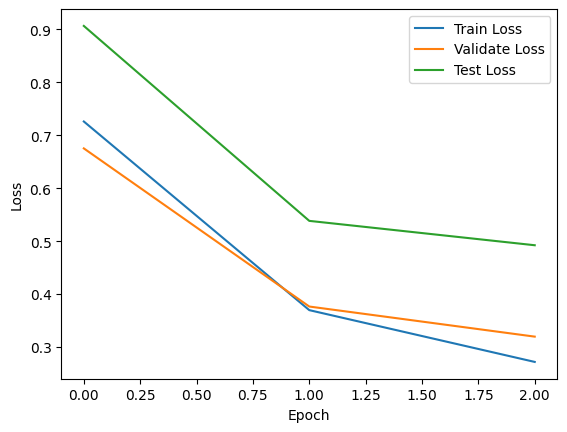

In [ ]:
# plot for performance for each epoch - loss vs epoch

fig, ax = plt.subplots()
ax.plot(train_losses, label='Train Loss')
ax.plot(val_losses, label='Validate Loss')
ax.plot(test_losses, label='Test Loss')
ax.set_xlabel('Epoch')  
ax.set_ylabel('MSE Loss')
ax.legend()
plt.show()



In [ ]:
# save train and test losses to csv
df = pd.DataFrame({'Train Loss': train_losses, 'Validate Loss': val_losses, 'Test Loss': test_losses})
df.to_csv(f'losses_{model_name}.csv', index=False)

## retrieve saved model

In [ ]:
# Load the saved model
checkpoint = torch.load(save_path)

# Create a new model instance
cnn_gru_model_loaded = CNN_GRU().to(device)

# Load the saved state
cnn_gru_model_loaded.load_state_dict(checkpoint["model_state_dict"])

# Optionally load other components
loaded_scaler_set = checkpoint["scaler_set"]
loaded_lag_selection = checkpoint["lag_selection"]
loaded_epoch = checkpoint["epoch"]

print(f"Model loaded from {save_path}")
print(f"Training stopped at epoch: {loaded_epoch}")
print(f"Lag selection: {loaded_lag_selection}")

# Set model to evaluation mode for inference
cnn_gru_model_loaded.eval()